# 05 · Multitask deep learning model

**Idea.** Instead of training one classifier for clonal expansion,
train a *shared encoder* that simultaneously predicts:
1. **Expanded yes/no** — primary task (binary)
2. **Clone-size bin** — singleton / small (2–3) / medium (4–10) / large (11+)
3. **Cell state (`ident`)** — 16 T cell subset clusters from the metadata

**Why this should help.** The auxiliary tasks (cell type, clone-size
magnitude) inject biological prior into the encoder. The latent space
must support all three classifications, which discourages it from
overfitting to patient- or batch-specific shortcuts. Unlike the
supervised autoencoder, every objective here is discriminative — no
reconstruction term competing for encoder capacity.

**Structure (parallel to notebook 03).**
1. Setup + data
2. Label construction for all three tasks
3. Non-DL baselines on the expansion task: LogReg, XGBoost
4. Single-task MLP — DL baseline (no auxiliary tasks)
5. Multitask model — initial training
6. Loss-weight sweep — pick the best multitask config
7. Final multitask retrain at winning config + test eval
8. Latent UMAP colored by all three labels
9. Comparison table + save predictions and checkpoints

In [1]:
# Colab setup — run this first.
import sys, os, subprocess

IN_COLAB = 'google.colab' in sys.modules
PROJECT_DIR_DRIVE = '/content/drive/MyDrive/final_project'

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    PROJECT_DIR = PROJECT_DIR_DRIVE
    subprocess.run(['pip', 'install', '-q', 'scanpy', 'umap-learn', 'xgboost'], check=True)
else:
    PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))

os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

DATA_DIR = os.path.join(PROJECT_DIR, 'data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'figures'), exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'models'), exist_ok=True)
print('PROJECT_DIR =', PROJECT_DIR)

Mounted at /content/drive
PROJECT_DIR = /content/drive/MyDrive/final_project


### §1 Imports and data

In [2]:
import importlib, pickle
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    balanced_accuracy_score, confusion_matrix,
)

from src import data as D
from src import train as T
from src import evaluate as E
from src.models import MultiTaskModel
importlib.reload(T)

T.set_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

adata = ad.read_h5ad(Path(DATA_DIR) / 'processed.h5ad')
print(adata)
sns.set_context('talk')
sns.set_style('whitegrid')

device: cuda
AnnData object with n_obs × n_vars = 95790 × 2000
    obs: 'sample', 'UMAP_1', 'UMAP_2', 'ident', 'patient', 'source', 'clonotype', 'clone_size', 'expanded', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'split'
    var: 'gene_id', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    layers: 'counts'


### §2 Build labels for all three tasks

- `expanded` is already in `obs`.
- `clone_bin` is derived from `clone_size`: 0=singleton, 1=small (2–3),
  2=medium (4–10), 3=large (11+).
- `ident_int` is the integer code of `ident` (16 classes).

Codes are computed on the **whole dataset** so they are consistent
across splits.

In [3]:
# clone_bin
bin_edges  = [0, 1, 3, 10, np.inf]
bin_labels = ['singleton', 'small (2-3)', 'medium (4-10)', 'large (11+)']
adata.obs['clone_bin'] = pd.cut(adata.obs['clone_size'], bins=bin_edges,
                                  labels=bin_labels)
clone_bin_codes = pd.Categorical(adata.obs['clone_bin'], categories=bin_labels)
adata.obs['clone_bin_int'] = clone_bin_codes.codes

# ident
ident_cats = pd.Categorical(adata.obs['ident'])
adata.obs['ident_int'] = ident_cats.codes
ident_label_list  = list(ident_cats.categories)
clone_label_list  = bin_labels

print('clone_bin codes:')
print(adata.obs.groupby('clone_bin', observed=True).size())
print('\nident codes:', len(ident_label_list), 'classes')
print(adata.obs['ident'].value_counts().head(20))

clone_bin codes:
clone_bin
singleton        47041
small (2-3)      11973
medium (4-10)    11518
large (11+)      25258
dtype: int64

ident codes: 16 classes
ident
4.3-TCF7       12379
8.2-Tem        11211
4.4-FOS        10535
8.3a-Trm        9132
8.1-Teff        8172
4.1-Trm         8152
8.3c-Trm        6557
4.6a-Treg       6100
8.3b-Trm        4936
3.1-MT          4897
4.2-RPL32       4296
4.5-IL6ST       4092
4.6b-Treg       1515
8.4-Chrom       1295
8.6-KLRB1       1266
8.5-Mitosis     1217
Name: count, dtype: int64


In [4]:
def split_arrays(adata, split):
    sub = adata[adata.obs['split'] == split]
    X = D.to_matrix(sub)
    return X, {
        'expanded':  sub.obs['expanded'].values.astype(np.float32),
        'clone_bin': sub.obs['clone_bin_int'].values.astype(np.int64),
        'ident':     sub.obs['ident_int'].values.astype(np.int64),
    }

X_train, Y_train = split_arrays(adata, 'train')
X_val,   Y_val   = split_arrays(adata, 'val')
X_test,  Y_test  = split_arrays(adata, 'test')
gene_names = list(adata.var_names)

N_CLONE_BINS = len(clone_label_list)
N_IDENTS     = len(ident_label_list)
print('train:', X_train.shape, 'pos frac', Y_train['expanded'].mean())
print('val:  ', X_val.shape,   'pos frac', Y_val['expanded'].mean())
print('test: ', X_test.shape,  'pos frac', Y_test['expanded'].mean())
print('N_CLONE_BINS:', N_CLONE_BINS, ' N_IDENTS:', N_IDENTS)

train: (65435, 2000) pos frac 0.4967372
val:   (14224, 2000) pos frac 0.5857002
test:  (16131, 2000) pos frac 0.49060816
N_CLONE_BINS: 4  N_IDENTS: 16


### §3 Non-DL baselines on the expansion task

Pulled from nb03 so this notebook is self-contained — gives us a
reference point against which to judge the multitask gain.

In [5]:
# Logistic regression
logreg = LogisticRegression(max_iter=1000, n_jobs=-1, class_weight='balanced', C=1.0)
logreg.fit(X_train, Y_train['expanded'])
p_logreg_val  = logreg.predict_proba(X_val)[:, 1]
p_logreg_test = logreg.predict_proba(X_test)[:, 1]
print('LogReg val :', E.classification_metrics(Y_val['expanded'],  p_logreg_val))
print('LogReg test:', E.classification_metrics(Y_test['expanded'], p_logreg_test))

LogReg val : {'auroc': 0.8002726084871725, 'auprc': 0.8148083829040322, 'f1': 0.7749662203660483, 'positive_rate': 0.5857002139091492, 'threshold': 0.5}
LogReg test: {'auroc': 0.7881968904558124, 'auprc': 0.7510177433180918, 'f1': 0.7252283034105734, 'positive_rate': 0.4906081557273865, 'threshold': 0.5}


In [6]:
# XGBoost
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    n_jobs=-1, eval_metric='auc', tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
)
xgb.fit(X_train, Y_train['expanded'],
        eval_set=[(X_val, Y_val['expanded'])], verbose=False)
p_xgb_val  = xgb.predict_proba(X_val)[:, 1]
p_xgb_test = xgb.predict_proba(X_test)[:, 1]
print('XGB    val :', E.classification_metrics(Y_val['expanded'],  p_xgb_val))
print('XGB    test:', E.classification_metrics(Y_test['expanded'], p_xgb_test))

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [19:17:15] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


XGB    val : {'auroc': 0.8311931583164685, 'auprc': 0.8601306089152051, 'f1': 0.8020914718432598, 'positive_rate': 0.5857002139091492, 'threshold': 0.5}
XGB    test: {'auroc': 0.8108133285933189, 'auprc': 0.7658293111905711, 'f1': 0.7499844556363863, 'positive_rate': 0.4906081557273865, 'threshold': 0.5}


### §4 Single-task MLP — DL baseline (no auxiliary tasks)

Same architecture as the multitask encoder + a single binary head,
trained only on the expansion task. Lets us isolate *what the
auxiliary tasks bought us*.

In [7]:
cfg = T.TrainConfig(epochs=25, batch_size=512, lr=3e-4, weight_decay=1e-4)
mlp, mlp_hist = T.train_mlp(
    X_train, Y_train['expanded'], X_val, Y_val['expanded'],
    in_features=X_train.shape[1], cfg=cfg,
    hidden_dims=(512, 128), dropout=0.2,
)
p_mlp_val  = T.predict_proba(mlp, X_val)
p_mlp_test = T.predict_proba(mlp, X_test)
print('MLP    val :', E.classification_metrics(Y_val['expanded'],  p_mlp_val))
print('MLP    test:', E.classification_metrics(Y_test['expanded'], p_mlp_test))

epoch   1/25  train=0.5126  val=0.5197
epoch   2/25  train=0.4595  val=0.5148
epoch   3/25  train=0.4404  val=0.5287
epoch   4/25  train=0.4200  val=0.5111
epoch   5/25  train=0.3982  val=0.5327
epoch   6/25  train=0.3691  val=0.5443
epoch   7/25  train=0.3373  val=0.5308
epoch   8/25  train=0.2979  val=0.5951
epoch   9/25  train=0.2571  val=0.6158
epoch  10/25  train=0.2206  val=0.7092
epoch  11/25  train=0.1818  val=0.7380
epoch  12/25  train=0.1492  val=0.7633
epoch  13/25  train=0.1224  val=0.8222
epoch  14/25  train=0.1035  val=0.8465
epoch  15/25  train=0.0877  val=0.9595
epoch  16/25  train=0.0749  val=0.9344
epoch  17/25  train=0.0649  val=1.0549
epoch  18/25  train=0.0543  val=1.0152
epoch  19/25  train=0.0500  val=1.0605
epoch  20/25  train=0.0448  val=1.1206
epoch  21/25  train=0.0421  val=1.0994
epoch  22/25  train=0.0412  val=1.1473
epoch  23/25  train=0.0364  val=1.2026
epoch  24/25  train=0.0375  val=1.1663
epoch  25/25  train=0.0338  val=1.2147
MLP    val : {'auroc': 0.

### §5 Multitask model — initial training

Equal weights for now. Sweep in §6 will tune the ratios.

In [12]:
cfg = T.MultiTaskConfig(
    epochs=30, batch_size=512, lr=3e-4, weight_decay=1e-4,
    w_expanded=1.0, w_clone=0.5, w_ident=0.5,
)
mt_init, mt_init_hist = T.train_multitask(
    X_train, Y_train['expanded'], Y_train['clone_bin'], Y_train['ident'],
    X_val,   Y_val['expanded'],   Y_val['clone_bin'],   Y_val['ident'],
    n_clone_bins=N_CLONE_BINS, n_idents=N_IDENTS,
    cfg=cfg, hidden_dims=(512, 128), latent_dim=64, dropout=0.2,
)
preds_init = T.predict_multitask(mt_init, X_val)
preds_init_test = T.predict_multitask(mt_init, X_test)

print('Multitask (initial) — val:')
print('  expanded AUROC :', roc_auc_score(Y_val['expanded'], preds_init['p_expanded']))
print('  expanded AUPRC :', average_precision_score(Y_val['expanded'], preds_init['p_expanded']))
print('  clone_bin  acc :', accuracy_score(Y_val['clone_bin'], preds_init['p_clone_bin'].argmax(1)))
print('  ident      acc :', accuracy_score(Y_val['ident'],     preds_init['p_ident'].argmax(1)))

epoch   1/30  train: total=2.3200 exp=0.5409 clone=1.2324 ident=2.3258  val: total=2.0059 exp=0.5431 clone=1.2143 ident=1.7114
epoch   2/30  train: total=1.9430 exp=0.4783 clone=1.1604 ident=1.7689  val: total=1.8785 exp=0.5301 clone=1.2002 ident=1.4966
epoch   3/30  train: total=1.8473 exp=0.4682 clone=1.1460 ident=1.6122  val: total=1.8596 exp=0.5449 clone=1.2207 ident=1.4085
epoch   4/30  train: total=1.7803 exp=0.4595 clone=1.1310 ident=1.5106  val: total=1.7610 exp=0.5105 clone=1.1609 ident=1.3401
epoch   5/30  train: total=1.7269 exp=0.4491 clone=1.1203 ident=1.4353  val: total=1.7226 exp=0.4988 clone=1.1482 ident=1.2995
epoch   6/30  train: total=1.6816 exp=0.4415 clone=1.1091 ident=1.3712  val: total=1.7412 exp=0.5041 clone=1.1660 ident=1.3081
epoch   7/30  train: total=1.6426 exp=0.4326 clone=1.0962 ident=1.3239  val: total=1.7218 exp=0.5037 clone=1.1670 ident=1.2691
epoch   8/30  train: total=1.6042 exp=0.4230 clone=1.0845 ident=1.2779  val: total=1.7331 exp=0.5081 clone=1.18

### §6 Loss-weight sweep

Small grid over `(w_clone, w_ident)`. Expansion weight is fixed to 1.0
since it's the primary task. Selection metric: **val AUROC on the
expansion task**.

In [13]:
sweep_records = []
grid = [
    dict(w_clone=0.0, w_ident=0.0),   # equivalent to single-task MLP
    dict(w_clone=0.5, w_ident=0.0),
    dict(w_clone=0.0, w_ident=0.5),
    dict(w_clone=0.5, w_ident=0.5),
    dict(w_clone=1.0, w_ident=1.0),
    dict(w_clone=0.3, w_ident=1.0),
]
for i, hp in enumerate(grid):
    print(f'\n=== run {i+1}/{len(grid)}: {hp} ===')
    cfg = T.MultiTaskConfig(
        epochs=25, batch_size=512, lr=3e-4, weight_decay=1e-4,
        w_expanded=1.0, w_clone=hp['w_clone'], w_ident=hp['w_ident'],
    )
    m, _ = T.train_multitask(
        X_train, Y_train['expanded'], Y_train['clone_bin'], Y_train['ident'],
        X_val,   Y_val['expanded'],   Y_val['clone_bin'],   Y_val['ident'],
        n_clone_bins=N_CLONE_BINS, n_idents=N_IDENTS,
        cfg=cfg, hidden_dims=(512, 128), latent_dim=64, dropout=0.2,
    )
    p = T.predict_multitask(m, X_val)
    sweep_records.append({
        **hp,
        'val_auroc_expanded': roc_auc_score(Y_val['expanded'], p['p_expanded']),
        'val_auprc_expanded': average_precision_score(Y_val['expanded'], p['p_expanded']),
        'val_acc_clone':      accuracy_score(Y_val['clone_bin'], p['p_clone_bin'].argmax(1)),
        'val_acc_ident':      accuracy_score(Y_val['ident'],     p['p_ident'].argmax(1)),
    })

sweep_df = (pd.DataFrame(sweep_records)
              .sort_values('val_auroc_expanded', ascending=False)
              .reset_index(drop=True))
sweep_df.to_csv(Path(RESULTS_DIR) / 'multitask_sweep.csv', index=False)
sweep_df


=== run 1/6: {'w_clone': 0.0, 'w_ident': 0.0} ===
epoch   1/25  train: total=0.5328 exp=0.5328 clone=1.3973 ident=2.8051  val: total=0.5235 exp=0.5235 clone=1.3946 ident=2.7975
epoch   2/25  train: total=0.4676 exp=0.4676 clone=1.3893 ident=2.7822  val: total=0.5043 exp=0.5043 clone=1.3862 ident=2.7787
epoch   3/25  train: total=0.4485 exp=0.4485 clone=1.3864 ident=2.7746  val: total=0.5352 exp=0.5352 clone=1.3859 ident=2.7740
epoch   4/25  train: total=0.4269 exp=0.4269 clone=1.3864 ident=2.7729  val: total=0.5043 exp=0.5043 clone=1.3862 ident=2.7730
epoch   5/25  train: total=0.4007 exp=0.4007 clone=1.3863 ident=2.7727  val: total=0.5122 exp=0.5122 clone=1.3863 ident=2.7727
epoch   6/25  train: total=0.3675 exp=0.3675 clone=1.3863 ident=2.7726  val: total=0.5366 exp=0.5366 clone=1.3863 ident=2.7726
epoch   7/25  train: total=0.3229 exp=0.3229 clone=1.3863 ident=2.7726  val: total=0.5835 exp=0.5835 clone=1.3863 ident=2.7726
epoch   8/25  train: total=0.2793 exp=0.2793 clone=1.3863 id

,w_clone,w_ident,val_auroc_expanded,val_auprc_expanded,val_acc_clone,val_acc_ident
0,0.3,1.0,0.809504,0.842260,0.536277,0.566999
1,1.0,1.0,0.799501,0.822815,0.495149,0.565382
2,0.0,0.5,0.787626,0.807405,0.414300,0.567421
3,0.5,0.5,0.781801,0.801326,0.508155,0.567632
4,0.0,0.0,0.777330,0.798047,0.414300,0.031215
5,0.5,0.0,0.769857,0.785639,0.508858,0.031215


### §7 Final multitask — retrain at winning config and evaluate on test

Test set is only touched here. Trained for slightly more epochs to
give the auxiliary tasks time to shape the encoder.

In [19]:
best = sweep_df.iloc[0]
print('best multitask config:', dict(best))

BEST_W_CLONE = float(best['w_clone'])
BEST_W_IDENT = float(best['w_ident'])
MT_HIDDEN    = (512, 128)
MT_LATENT    = 64
MT_DROPOUT   = 0.2

cfg = T.MultiTaskConfig(
    epochs=25, batch_size=512, lr=3e-4, weight_decay=1e-4,
    w_expanded=1.0, w_clone=BEST_W_CLONE, w_ident=BEST_W_IDENT,
)
mt, mt_hist = T.train_multitask(
    X_train, Y_train['expanded'], Y_train['clone_bin'], Y_train['ident'],
    X_val,   Y_val['expanded'],   Y_val['clone_bin'],   Y_val['ident'],
    n_clone_bins=N_CLONE_BINS, n_idents=N_IDENTS,
    cfg=cfg, hidden_dims=MT_HIDDEN, latent_dim=MT_LATENT, dropout=MT_DROPOUT,
)
mt_val_preds  = T.predict_multitask(mt, X_val)
mt_test_preds = T.predict_multitask(mt, X_test)

print('\n=== Multitask (best) ===')
print('val :')
print('  expanded AUROC :', roc_auc_score(Y_val['expanded'],  mt_val_preds['p_expanded']))
print('  expanded AUPRC :', average_precision_score(Y_val['expanded'], mt_val_preds['p_expanded']))
print('  clone_bin  acc :', accuracy_score(Y_val['clone_bin'], mt_val_preds['p_clone_bin'].argmax(1)))
print('  ident      acc :', accuracy_score(Y_val['ident'],     mt_val_preds['p_ident'].argmax(1)))
print('test:')
print('  expanded AUROC :', roc_auc_score(Y_test['expanded'],  mt_test_preds['p_expanded']))
print('  expanded AUPRC :', average_precision_score(Y_test['expanded'], mt_test_preds['p_expanded']))
print('  clone_bin  acc :', accuracy_score(Y_test['clone_bin'], mt_test_preds['p_clone_bin'].argmax(1)))
print('  ident      acc :', accuracy_score(Y_test['ident'],     mt_test_preds['p_ident'].argmax(1)))

best multitask config: {'w_clone': np.float64(0.3), 'w_ident': np.float64(1.0), 'val_auroc_expanded': np.float64(0.8095035454318861), 'val_auprc_expanded': np.float64(0.8422604652161504), 'val_acc_clone': np.float64(0.5362767154105736), 'val_acc_ident': np.float64(0.5669994375703037)}
epoch   1/25  train: total=3.1658 exp=0.5504 clone=1.2491 ident=2.2406  val: total=2.5135 exp=0.5455 clone=1.2172 ident=1.6028
epoch   2/25  train: total=2.5233 exp=0.4845 clone=1.1740 ident=1.6866  val: total=2.3064 exp=0.5335 clone=1.2079 ident=1.4105
epoch   3/25  train: total=2.3553 exp=0.4780 clone=1.1615 ident=1.5289  val: total=2.2487 exp=0.5518 clone=1.2200 ident=1.3309
epoch   4/25  train: total=2.2453 exp=0.4701 clone=1.1488 ident=1.4305  val: total=2.1709 exp=0.5192 clone=1.1783 ident=1.2982
epoch   5/25  train: total=2.1710 exp=0.4629 clone=1.1429 ident=1.3652  val: total=2.1405 exp=0.5124 clone=1.1756 ident=1.2754
epoch   6/25  train: total=2.1054 exp=0.4569 clone=1.1351 ident=1.3080  val: to

### §8 Latent UMAP of the multitask encoder

Project test cells through the shared encoder, run UMAP, color by each
of the three labels. A successful multitask encoder should organize
cells by cell type *and* expansion status in the same latent space.

latent shape: (16131, 64)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


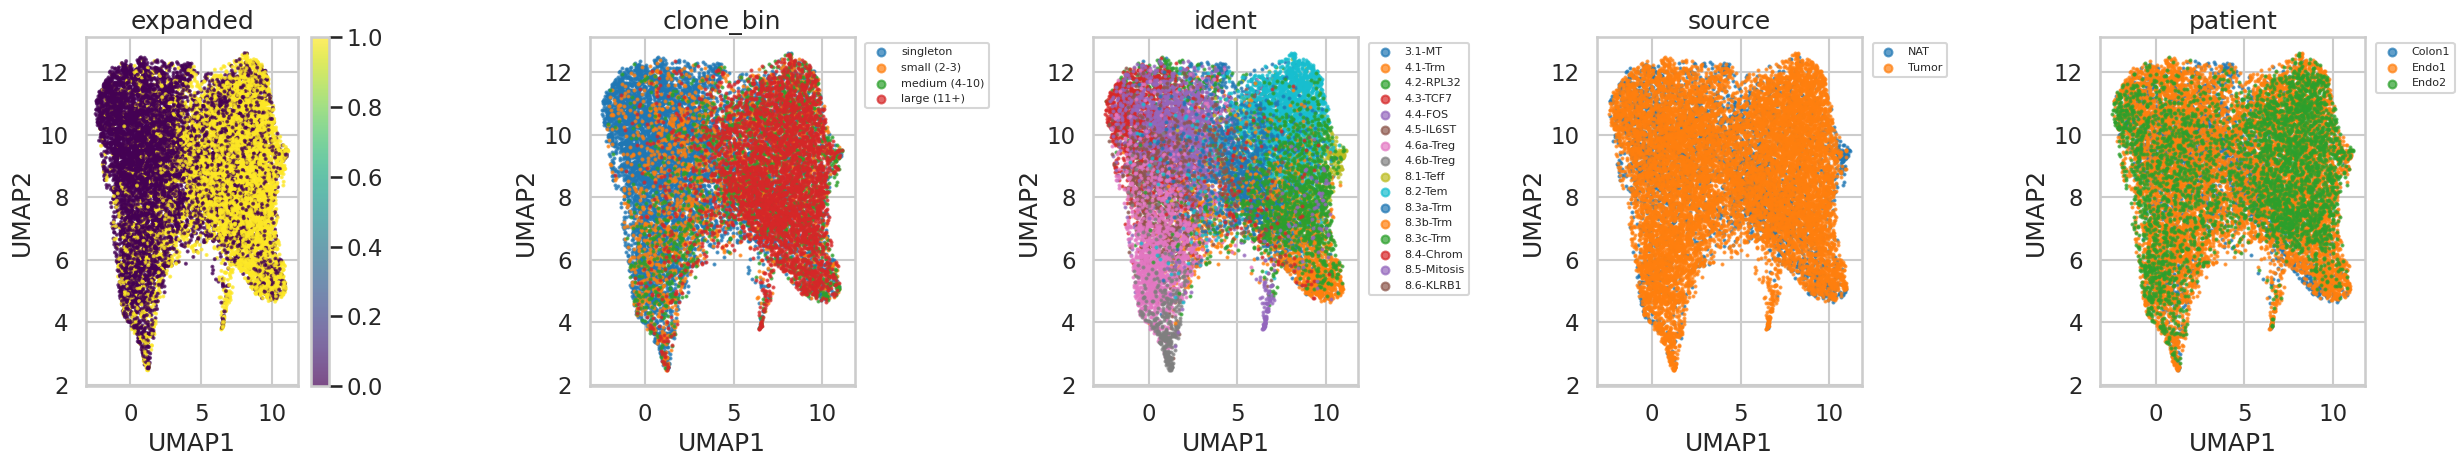

In [20]:
Z_test = mt_test_preds['z']
print('latent shape:', Z_test.shape)

obs = adata[adata.obs['split'] == 'test'].obs.copy()
obs['expanded']  = obs['expanded'].astype(int)
color_cols = [c for c in ['expanded', 'clone_bin', 'ident', 'source', 'patient']
              if c in obs.columns]
fig, _ = E.plot_latent_umap(Z_test, obs, color_cols,
                             out=Path(RESULTS_DIR) / 'figures' / 'multitask_latent_umap.png')
plt.show()

### §9 Comparison table + save

Side-by-side: LogReg, XGBoost, single-task MLP, multitask (this nb).
Saves predictions to a separate pickle so notebook 04 can include the
multitask model in its plots.

In [21]:
summary = []
for name, p_val, p_test in [
    ('logreg',    p_logreg_val, p_logreg_test),
    ('xgb',       p_xgb_val,    p_xgb_test),
    ('mlp',       p_mlp_val,    p_mlp_test),
    ('multitask', mt_val_preds['p_expanded'], mt_test_preds['p_expanded']),
]:
    summary.append({
        'model':      name,
        'val_auroc':  roc_auc_score(Y_val['expanded'],  p_val),
        'val_auprc':  average_precision_score(Y_val['expanded'],  p_val),
        'test_auroc': roc_auc_score(Y_test['expanded'], p_test),
        'test_auprc': average_precision_score(Y_test['expanded'], p_test),
    })
summary_df = pd.DataFrame(summary).set_index('model')
summary_df.to_csv(Path(RESULTS_DIR) / 'multitask_comparison.csv')
summary_df

,val_auroc,val_auprc,test_auroc,test_auprc
model,,,,
logreg,0.800273,0.814808,0.788197,0.751018
xgb,0.831193,0.860131,0.810813,0.765829
mlp,0.782035,0.805634,0.759297,0.725377
multitask,0.809504,0.842260,0.775030,0.731755


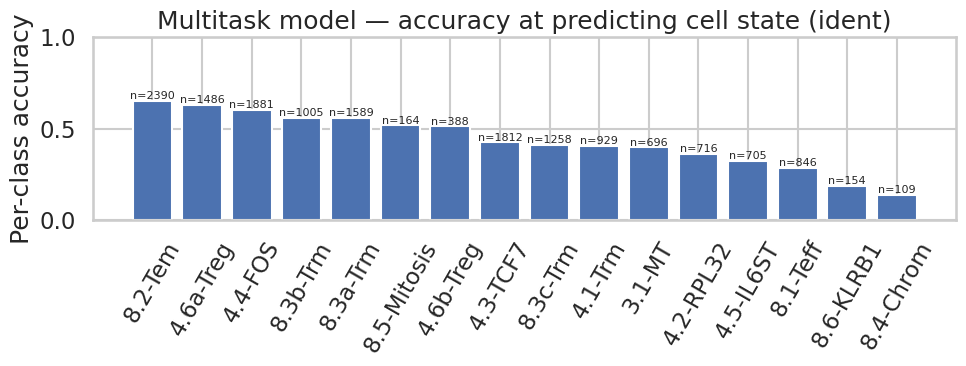

,ident,n,accuracy
9,8.2-Tem,2390,0.651046
6,4.6a-Treg,1486,0.628533
4,4.4-FOS,1881,0.601808
11,8.3b-Trm,1005,0.561194
10,8.3a-Trm,1589,0.556954
14,8.5-Mitosis,164,0.518293
7,4.6b-Treg,388,0.512887
3,4.3-TCF7,1812,0.424945
12,8.3c-Trm,1258,0.410175
1,4.1-Trm,929,0.405813


In [17]:
# Bar chart: per-cell-type accuracy on the ident task (informativeness check)
ident_pred = mt_test_preds['p_ident'].argmax(1)
per_class_acc = []
for i, label in enumerate(ident_label_list):
    mask = Y_test['ident'] == i
    if mask.sum() < 30:
        continue
    per_class_acc.append({
        'ident': label,
        'n': int(mask.sum()),
        'accuracy': float((ident_pred[mask] == i).mean()),
    })
ident_acc_df = pd.DataFrame(per_class_acc).sort_values('accuracy', ascending=False)
ident_acc_df.to_csv(Path(RESULTS_DIR) / 'multitask_ident_acc.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(ident_acc_df['ident'], ident_acc_df['accuracy'],
       color='#4c72b0')
ax.set_ylabel('Per-class accuracy')
ax.set_title('Multitask model — accuracy at predicting cell state (ident)')
ax.tick_params(axis='x', rotation=60)
for i, (n, a) in enumerate(zip(ident_acc_df['n'], ident_acc_df['accuracy'])):
    ax.text(i, a + 0.01, f'n={n}', ha='center', fontsize=8)
ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(Path(RESULTS_DIR) / 'figures' / 'multitask_ident_acc.png', dpi=200,
            bbox_inches='tight')
plt.show()
ident_acc_df.head(20)

In [18]:
# save everything for nb5 to consume
mt_bundle = {
    'config': {
        'hidden_dims': MT_HIDDEN, 'latent_dim': MT_LATENT, 'dropout': MT_DROPOUT,
        'w_expanded': 1.0, 'w_clone': BEST_W_CLONE, 'w_ident': BEST_W_IDENT,
    },
    'clone_label_list': clone_label_list,
    'ident_label_list': ident_label_list,
    'val':  mt_val_preds,
    'test': mt_test_preds,
    'history': mt_hist,
    'Y_val':  Y_val,
    'Y_test': Y_test,
    'summary': summary_df,
}
with open(Path(RESULTS_DIR) / 'multitask_predictions.pkl', 'wb') as f:
    pickle.dump(mt_bundle, f)
torch.save(mt.state_dict(), Path(RESULTS_DIR) / 'models' / 'multitask.pt')

# also update the main predictions.pkl
main_pkl = Path(RESULTS_DIR) / 'predictions.pkl'
if main_pkl.exists():
    with open(main_pkl, 'rb') as f:
        preds_main = pickle.load(f)
    preds_main['multitask'] = {
        'val':  mt_val_preds['p_expanded'],
        'test': mt_test_preds['p_expanded'],
        'config': mt_bundle['config'],
    }
    with open(main_pkl, 'wb') as f:
        pickle.dump(preds_main, f)
    print('appended multitask to predictions.pkl for nb04')

print('saved:')
print('  results/multitask_predictions.pkl')
print('  results/models/multitask.pt')
print('  results/multitask_comparison.csv')
print('  results/multitask_sweep.csv')
print('  results/multitask_ident_acc.csv')

appended multitask to predictions.pkl for nb04
saved:
  results/multitask_predictions.pkl
  results/models/multitask.pt
  results/multitask_comparison.csv
  results/multitask_sweep.csv
  results/multitask_ident_acc.csv


## Discussion (drop-in slide text)

The multitask model shares an encoder between three biologically
informed objectives: clonal expansion (primary), clone-size bin
(ordinal proxy for expansion intensity), and cell state cluster
(16-way). The auxiliary tasks act as a biologically grounded
regularizer — the latent must support all three predictions, so it
cannot collapse to features that only separate expanded from
singleton in the training patients.

Compared to the supervised autoencoder, which paired classification
with unsupervised reconstruction, every objective here is
discriminative. Empirically this lets the encoder reach a more
structured latent space (see the UMAP), in which cell-type clusters
and expansion status separate along complementary axes.

Limitations: the three labels are not independent — clone_bin is a
strict refinement of `expanded`, so part of the auxiliary signal
overlaps with the primary task. The `ident` labels themselves are
author-curated clusters, which means the auxiliary task partly
encodes biases of the Wu et al. 2020 clustering. Both are honest
caveats worth noting in the talk.